# Blank nlp pipeline

In [25]:
import spacy

 **nlp = spacy.blank("er") is a blank pipeline in nlp**

 nlp.pipe_names --> {[]}

In [19]:
nlp = spacy.blank("en")
doc = nlp("Caption america ate 100$ of samosa.Ten he said I can do this all day.")

for token in doc:
    print(token)

Caption
america
ate
100
$
of
samosa
.
Ten
he
said
I
can
do
this
all
day
.


In [21]:
doc = nlp("Captain america ate 100$ of samosa. Then he said I can do this all day. ")

for token in doc:
  print(token.text, " | ", spacy.explain(token.pos_), " | ", token.lemma_)

Captain  |  None  |  
america  |  None  |  
ate  |  None  |  
100  |  None  |  
$  |  None  |  
of  |  None  |  
samosa  |  None  |  
.  |  None  |  
Then  |  None  |  
he  |  None  |  
said  |  None  |  
I  |  None  |  
can  |  None  |  
do  |  None  |  
this  |  None  |  
all  |  None  |  
day  |  None  |  
.  |  None  |  


/usr/local/lib/python3.13/dist-packages/spacy/glossary.py:20: UserWarning: [W118] Term '' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))


We get above error because we have a blank pipeline as shown below. Pipeline is something that starts with a Tokenizer component in a dotted rectange below. You can see there is nothing there hence the blank pipeline
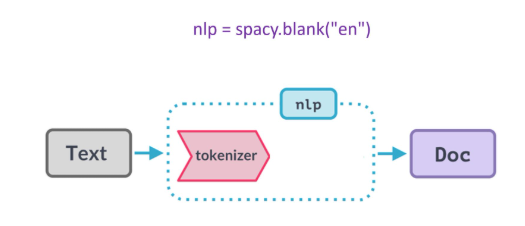

In [22]:
nlp.pipe_names

[]

nlp.pipe_names is empty array indicating no components in the pipeline. Pipeline is something that starts with a tokenizer

More general diagram for nlp pipeline may look something like below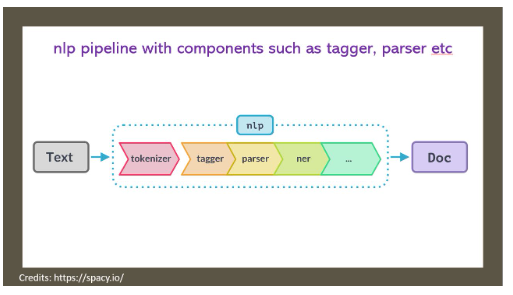

# Download trained pipeline
To download trained pipeline use a command such as,

python -m spacy download en_core_web_sm

This downloads the small (sm) pipeline for english language

Further instructions on : https://spacy.io/usage/models#quickstart

In [15]:
nlp1 = spacy.load("en_core_web_sm")
nlp1.pipe_names

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

In [16]:
nlp1.pipeline

[('tok2vec', <spacy.pipeline.tok2vec.Tok2Vec at 0x7d284c5265d0>),
 ('tagger', <spacy.pipeline.tagger.Tagger at 0x7d284c524d10>),
 ('parser', <spacy.pipeline.dep_parser.DependencyParser at 0x7d284c26e810>),
 ('attribute_ruler',
  <spacy.pipeline.attributeruler.AttributeRuler at 0x7d284c2ae6d0>),
 ('lemmatizer',
  <spacy.lang.en.lemmatizer.EnglishLemmatizer at 0x7d284c2af310>),
 ('ner', <spacy.pipeline.ner.EntityRecognizer at 0x7d284c26e6c0>)]

In [17]:
doc = nlp1("Captain america ate 100$ of samosa. Then he said I can do this all day. ")

for token in doc:
  print(token.text, " | ", spacy.explain(token.pos_), " | ", token.lemma_)

Captain  |  proper noun  |  Captain
america  |  proper noun  |  america
ate  |  verb  |  eat
100  |  numeral  |  100
$  |  numeral  |  $
of  |  adposition  |  of
samosa  |  proper noun  |  samosa
.  |  punctuation  |  .
Then  |  adverb  |  then
he  |  pronoun  |  he
said  |  verb  |  say
I  |  pronoun  |  I
can  |  auxiliary  |  can
do  |  verb  |  do
this  |  pronoun  |  this
all  |  determiner  |  all
day  |  noun  |  day
.  |  punctuation  |  .


 **Run same code above with a blank pipeline and check what output you see?**

# **Named Entity Recognition**

Ye thoda sa manula method hai

In [29]:
sample_Pipe =  spacy.load("en_core_web_sm")
null_pipe = spacy.blank("en")

null_pipe.add_pipe("ner", source=sample_Pipe)
null_pipe.pipe_names


['ner']

In [30]:
doc = null_pipe("Tesla Inc is going to acquire twitter for $45 billion")
for ent in doc.ents:
  print(ent.text, " | ", ent.label_, " | ", spacy.explain(ent.label_))

Tesla Inc  |  ORG  |  Companies, agencies, institutions, etc.
$45 billion  |  MONEY  |  Monetary values, including unit


2. method

In [36]:
doc = sample_Pipe("Tesla Inc is going to acquire twitter for $45 billion")
for ent in doc.ents:
    print(ent.text, ent.label_)

Tesla Inc ORG
$45 billion MONEY


In [37]:
from spacy import displacy

displacy.render(doc, style="ent")

# **Trained processing pipeline in French**

In [44]:
nlp = spacy.load("fr_core_news_sm")

OSError: [E050] Can't find model 'fr_core_news_sm'. It doesn't seem to be a Python package or a valid path to a data directory.

You need to install the processing pipeline for french language using this command,

python -m spacy download fr_core_news_sm

In [46]:
!python -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 42.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [47]:
nlp = spacy.load("fr_core_news_sm")

In [48]:
doc = nlp("Tesla Inc va racheter Twitter pour $45 milliards de dollars")
for ent in doc.ents:
    print(ent.text, " | ", ent.label_, " | ", spacy.explain(ent.label_))

Tesla Inc  |  PER  |  Named person or family.
Twitter  |  MISC  |  Miscellaneous entities, e.g. events, nationalities, products or works of art


In [49]:
for token in doc:
    print(token, " | ", token.pos_, " | ", token.lemma_)

Tesla  |  PROPN  |  Tesla
Inc  |  PROPN  |  Inc
va  |  VERB  |  aller
racheter  |  VERB  |  racheter
Twitter  |  VERB  |  twitter
pour  |  ADP  |  pour
$  |  NOUN  |  dollar
45  |  NUM  |  45
milliards  |  NOUN  |  milliard
de  |  ADP  |  de
dollars  |  NOUN  |  dollar


# **Adding a component to a blank pipeline**

In [50]:
source_nlp = spacy.load("en_core_web_sm")

nlp = spacy.blank("en")
nlp.add_pipe("ner", source=source_nlp)
nlp.pipe_names

['ner']

In [51]:
doc = nlp("Tesla Inc is going to acquire twitter for $45 billion")
for ent in doc.ents:
    print(ent.text, ent.label_)

Tesla Inc ORG
$45 billion MONEY


In below image you can see sentecizer component in the pipeline

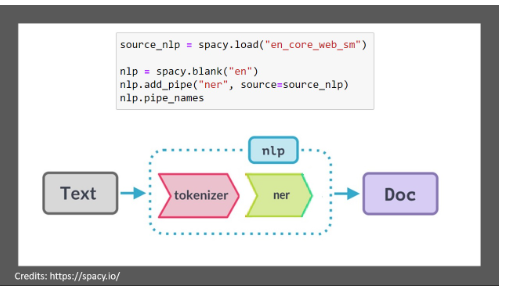

Further reading

https://spacy.io/usage/processing-pipelines#pipelines